# Which way does a player lean?

Notebook 16 gave the throw a tilt and asked three questions of it. Does a lean
change the board? **Yes** -- 0.61 visits a leg between the best and worst
orientation of an identical ellipse, from the board's *numbering* rather than its
geometry, because the 20 is flanked by the 1 and the 5. Can it be learned from
scores? **Yes, more easily than the spread** -- about 93 darts at the bull pin
$\rho$ to $\pm 0.1$, because a score is fundamentally a statement about which
*segment* a dart landed in, and that is angular information. What does ignoring
it cost? About 0.15 visits a leg.

And then it ended on this:

> The prior on $\rho$ is doing real work at these sample sizes, and it is
> currently a guess: centred on no lean with a standard deviation of 0.3. What
> real players' leans actually look like would change the shrinkage, and nobody
> knows.

Notebook 16 was entirely simulated. This notebook measures seventeen real ones.

Two things make it harder than notebook 16's "93 darts" suggests. The bull was
chosen *because* every segment boundary meets there; competition darts are thrown
at the treble 20 and its three step-down neighbours, nowhere near it. And the
elliptical families in `throw_families.py` pin the ellipse to the board's
vertical and horizontal, so they cannot see a lean at all -- a group leaning 45
degrees has equal marginal spreads and reads as perfectly round. Both are fixed
below, and the second one first.

In [1]:
import os
import sys
module_path = os.path.abspath(os.path.join('..', '..'))
if module_path not in sys.path:
    sys.path.append(module_path)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.25,
    'grid.linewidth': 0.6, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.titlesize': 11, 'font.size': 9, 'legend.frameon': False,
})

from darts.hierarchical import delta_interval, heterogeneity, random_effects
from darts.throw_families import FAMILIES, RadialBedGrid
from darts.throw_shape import principal_axes

TILT = FAMILIES['tilted-t']
RES = os.path.join(module_path, 'results', 'heterogeneity')
FITS = pd.read_csv(os.path.join(RES, 'players.csv'))
Z = np.load(os.path.join(RES, 'visits.npz'), allow_pickle=True)
HALF = pd.read_csv(os.path.join(RES, 'split_half.csv'))
print(f'{len(FITS)} players, {FITS.n_train.sum():,} training visits, '
      f'{FITS.n_test.sum():,} held out')

17 players, 5,429 training visits, 5,469 held out


## 1 · Two numbers, not a ratio and an angle

The obvious parameterisation of a leaning ellipse is its elongation and its
angle. It has a hole in it: a **round** group has no angle. Every tilt describes
it equally well, so the likelihood has a whole ridge of equivalent parameters and
an optimiser walks along it -- and since the elongations notebook 24 fitted to
real players sit near 1, that ridge is exactly where these fits live.

So the shape is carried as

$$e_1 = \log(\text{ratio})\cos 2\theta, \qquad e_2 = \log(\text{ratio})\sin 2\theta$$

which is one point, the origin, for a round group. The doubling is what makes it
continuous: a tilt has period $\pi$, not $2\pi$ -- a group leaning 30 degrees and
one leaning 210 are the same group -- so it is $2\theta$ that goes round once.

What gets quoted is $\rho$, the correlation of the scale matrix, because that is
what `throw_shape.py` and the particle filter already carry. It is worth knowing
that it is zero in **two** different ways.

In [2]:
def shape(ratio, deg, nu=2.4):
    lr, th = np.log(ratio), np.radians(deg)
    return np.array([np.log(nu - 2), lr * np.cos(2 * th), lr * np.sin(2 * th)])

print('rho against the lean, for a group elongated 1.6:1:')
for deg in (0, 15, 30, 45, 60, 90, 135):
    S = TILT.scale_matrix(1.0, shape(1.6, deg))
    major, minor, angle = principal_axes(S)
    print(f'   lean {deg:3d} deg ->  rho {TILT.rho(shape(1.6, deg)):+.4f}   '
          f'(major axis {angle:5.1f} deg from the x axis; vertical is 90)')
print()
print('and the two ways it is zero:')
print(f'   a round group leaning 30 deg :  rho {TILT.rho(shape(1.0, 30)):+.4f}')
print(f'   a 1.6:1 group square to the board: rho {TILT.rho(shape(1.6, 0)):+.4f}')
print('\nso rho measures the *interaction* of elongation and lean, not the lean.')

rho against the lean, for a group elongated 1.6:1:
   lean   0 deg ->  rho +0.0000   (major axis  90.0 deg from the x axis; vertical is 90)
   lean  15 deg ->  rho +0.2368   (major axis  75.0 deg from the x axis; vertical is 90)
   lean  30 deg ->  rho +0.3889   (major axis  60.0 deg from the x axis; vertical is 90)
   lean  45 deg ->  rho +0.4382   (major axis  45.0 deg from the x axis; vertical is 90)
   lean  60 deg ->  rho +0.3889   (major axis  30.0 deg from the x axis; vertical is 90)
   lean  90 deg ->  rho +0.0000   (major axis   0.0 deg from the x axis; vertical is 90)
   lean 135 deg ->  rho -0.4382   (major axis 135.0 deg from the x axis; vertical is 90)

and the two ways it is zero:
   a round group leaning 30 deg :  rho +0.0000
   a 1.6:1 group square to the board: rho +0.0000

so rho measures the *interaction* of elongation and lean, not the lean.


Note the shape of that. $\rho$ peaks at a 45 degree lean and returns to zero at
90 -- because a group stretched *horizontally* is as square to the board as one
stretched vertically. And it is zero for a round group at any angle.

So $\rho$ is not "the lean". It is the lean multiplied by how much there is to
lean, and a player can score zero on it either by being round or by being
upright. That matters for reading the table below: a $\rho$ near zero is not
evidence of a round group.

## 2 · What seventeen professionals actually look like

Each player is fitted a tilted Student-t on half their legs, and the uncertainty
comes from the curvature of their own likelihood. Two things about that are
worth stating before the numbers.

The finite-difference step is checked at two sizes, because a Hessian that
depends on its step is not a Hessian. It caught something immediately: for the
players whose $\nu$ has run to the $\nu > 2$ clip that notebook 24 found five of
them sitting on, the likelihood is flat in that direction, the numerical
curvature there is noise, and it poisons the whole matrix. Those players have
$\nu$ held where the constraint put it, and their remaining standard errors are
*conditional* on that.

In [3]:
rows = []
for i, r in FITS.iterrows():
    th, cov = Z[f'{i}_theta'], Z[f'{i}_cov']
    sub = cov[np.ix_([3, 4], [3, 4])]
    if not np.isfinite(sub).all():
        rows.append(dict(player=r.player, n=r.n_train, rho=r.rho,
                         lo=np.nan, hi=np.nan, width=np.nan))
        continue
    o = delta_interval(lambda e: TILT.rho(np.array([th[2], e[0], e[1]])),
                       th[3:5], sub, seed=i)
    rows.append(dict(player=r.player, n=r.n_train, rho=r.rho, lo=o['lo'],
                     hi=o['hi'], width=o['hi'] - o['lo']))
rho = pd.DataFrame(rows)
rho['excludes_0'] = (rho.lo > 0) | (rho.hi < 0)
print('rho per player, with a 95% interval:')
print(rho.round(3).to_string(index=False))
ok = rho.lo.notna()
print(f"\nmedian interval width {rho.width.median():.3f}  (about +/-"
      f"{rho.width.median() / 2:.2f})")
print(f"{int(rho.excludes_0.sum())} of {int(ok.sum())} exclude zero; "
      f"{0.05 * ok.sum():.1f} expected by chance")
print(f"spread of the point estimates: sd {FITS.rho.std(ddof=1):.3f}, "
      f"range {FITS.rho.min():+.3f} to {FITS.rho.max():+.3f}")
print(f"\nfor comparison, notebook 16 pinned rho to +/-0.1 from 93 darts "
      f"at the bull.\nthese players threw {FITS.n_train.min() * 3:,} to "
      f"{FITS.n_train.max() * 3:,} darts each, at the treble 20.")

rho per player, with a 95% interval:
               player   n    rho     lo     hi  width  excludes_0
         Peter Wright 650 -0.028 -0.196  0.140  0.336       False
   Michael van Gerwen 530 -0.087 -0.266  0.100  0.366       False
Raymond van Barneveld 389 -0.024 -0.227  0.177  0.405       False
         Daryl Gurney 367  0.173 -0.075  0.402  0.477       False
        Gary Anderson 348  0.097 -0.103  0.287  0.390       False
          Phil Taylor 338 -0.171 -0.481  0.178  0.659       False
        Dave Chisnall 307  0.046 -0.202  0.292  0.494       False
         Gerwyn Price 285  0.200 -0.099  0.462  0.561       False
           James Wade 275  0.275  0.006  0.509  0.503        True
      Mensur Suljovic 263  0.048 -0.204  0.301  0.505       False
       Simon Whitlock 266 -0.187 -0.415  0.064  0.480       False
        Michael Smith 264  0.015 -0.231  0.255  0.486       False
        Jelle Klaasen 257 -0.299 -0.490 -0.082  0.408        True
         Adrian Lewis 257  0.208 -0.208

**A player's lean is barely measurable from competition darts.**

The median 95% interval is **0.49 wide** -- about $\pm 0.25$ -- against point
estimates that only span $-0.30$ to $+0.31$ in the first place. Two of the
sixteen intervals exclude zero, and 0.8 would be expected to by chance, so that
is not a finding either.

Set against notebook 16, the gap is the whole story. It pinned $\rho$ to
$\pm 0.1$ from **93 darts** at the bull. These players threw **612 to 1,950**
darts each and land at $\pm 0.25$. Twenty times the darts for two and a half
times the *worse* answer, because they were thrown at the treble 20 rather than
at the bull, where every segment boundary meets. Notebook 16 chose the bull for
exactly this reason and said so; this is what the choice was worth.

### How much of that is real?

A standard error from the curvature of a likelihood is an asymptotic promise. The
direct version of the question needs no promise: fit each player **twice, on
disjoint halves of their own legs**, and see whether the two answers agree.

(Refitting on a different random *split* would not do. Two random halves of the
same legs share about half their data, and duly correlate at +0.88, which
measures the overlap rather than the reliability.)

In [4]:
r_rho = HALF.rho.corr(HALF.rho_other_half)
r_ratio = HALF.ratio.corr(HALF.ratio_other_half)
sb = lambda r: 2 * r / (1 + r)
print('the same player, fitted on two disjoint halves of their own legs:')
print(HALF[['player', 'n_train', 'rho', 'rho_other_half',
            'ratio', 'ratio_other_half']].round(3).to_string(index=False))
print(f'\nsplit-half correlation:      rho {r_rho:+.3f}   elongation {r_ratio:+.3f}')
print(f'Spearman-Brown, whole record: rho {sb(r_rho):+.3f}   '
      f'elongation {sb(r_ratio):+.3f}')
print('\nso roughly %.0f%% of the between-player variance in rho is signal.'
      % (100 * sb(r_rho)))

the same player, fitted on two disjoint halves of their own legs:
               player  n_train    rho  rho_other_half  ratio  ratio_other_half
         Peter Wright      650 -0.028           0.026  1.073             1.080
   Michael van Gerwen      530 -0.087          -0.077  1.113             1.280
Raymond van Barneveld      389 -0.024          -0.070  1.421             1.394
         Daryl Gurney      367  0.173           0.084  1.212             1.129
        Gary Anderson      348  0.097           0.040  1.164             1.072
          Phil Taylor      338 -0.171          -0.029  1.244             1.166
        Dave Chisnall      307  0.046          -0.026  1.122             1.387
         Gerwyn Price      285  0.200           0.024  1.285             1.208
           James Wade      275  0.275           0.044  1.718             1.115
      Mensur Suljovic      263  0.048          -0.074  1.580             1.630
       Simon Whitlock      266 -0.187          -0.012  1.249     

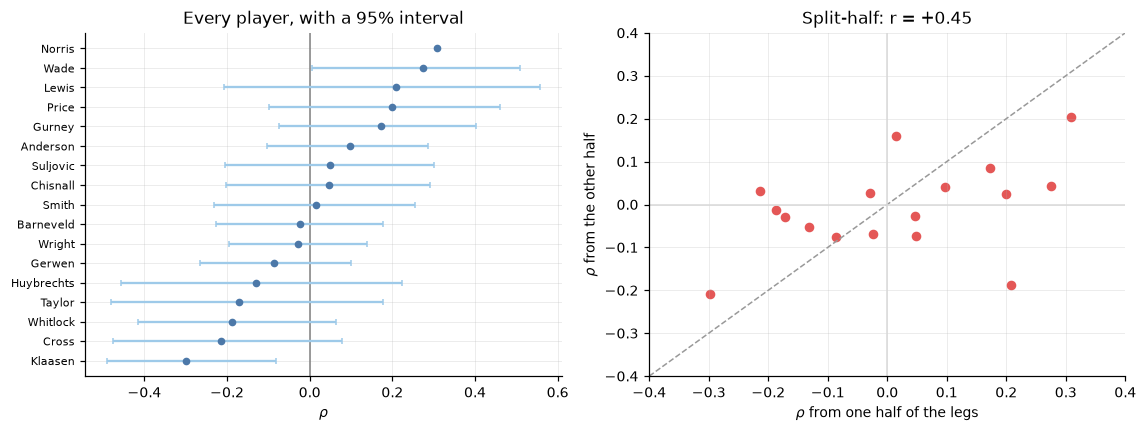

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(10.5, 4.0))
o = rho.sort_values('rho')
y = np.arange(len(o))
ax[0].axvline(0, color='0.5', lw=1)
ax[0].errorbar(o.rho, y, xerr=[o.rho - o.lo, o.hi - o.rho], fmt='o', ms=4,
               color='#4c78a8', ecolor='#9ecae9', capsize=2)
ax[0].set_yticks(y, [p.split()[-1] for p in o.player], fontsize=7.5)
ax[0].set(xlabel=r'$\rho$', title=r'Every player, with a 95% interval')

lim = 0.4
ax[1].plot([-lim, lim], [-lim, lim], color='0.6', lw=1, ls='--')
ax[1].axhline(0, color='0.85', lw=1); ax[1].axvline(0, color='0.85', lw=1)
ax[1].scatter(HALF.rho, HALF.rho_other_half, s=28, color='#e45756')
ax[1].set(xlabel=r'$\rho$ from one half of the legs',
          ylabel=r'$\rho$ from the other half',
          xlim=(-lim, lim), ylim=(-lim, lim),
          title=f'Split-half: r = {r_rho:+.2f}')
fig.tight_layout()

**About 62% of it is real.**

The split-half correlation is $+0.447$, and Spearman-Brown says a player's whole
competition record would give $+0.62$. So roughly three fifths of the variation
between these seventeen numbers is a property of the players and two fifths is
noise.

The scatter plot shows what that looks like in practice: the extremes replicate
and the middle does not. Klaasen comes back $-0.299$ then $-0.208$, Norris
$+0.309$ then $+0.204$, van Gerwen $-0.087$ then $-0.077$. But Adrian Lewis goes
from $+0.208$ to $-0.186$ -- a complete reversal -- and Rob Cross from $-0.214$
to $+0.031$. Anyone quoting one of these players' leans as a fact would be right
about a third of the time and confidently wrong about a fifth.

Elongation is no better: $+0.392$, or $+0.56$ for a whole record.

## 3 · Do players differ, and is there a lean to speak of?

Two separate questions, and conflating them is the usual mistake. "Is there a
population lean?" is about the *mean*; "do players lean differently?" is about
the *spread*. Both are asked in the $(e_1, e_2)$ coordinates, which is where they
are unbounded and non-periodic and so where averaging across players means
something.

The two coordinates also split the question usefully. $e_1$ is elongation square
to the board -- taller than wide, or wider than tall. $e_2$ is elongation on the
diagonal, which is exactly the component an axis-aligned model cannot see.

In [6]:
for name, label, what in (
        ('e1', 'e1: elongation square to the board', 'preferred orientation'),
        ('e2', 'e2: elongation on the diagonal -- the lean', 'population lean')):
    m = FITS['se_' + name].notna()
    est, se = FITS.loc[m, name].values, FITS.loc[m, 'se_' + name].values
    h, r = heterogeneity(est, se), random_effects(est, se)
    print(f'{label}')
    print(f'   population mean  mu = {r["mu"]:+.3f} (se {r["se_mu"]:.3f})   '
          f'-> {"no" if abs(r["mu"]) < 2 * r["se_mu"] else "a"} {what}')
    print(f'   spread across players  tau = {r["tau"]:.3f}')
    print(f'   I2 = {h["I2"]:.2f}, Q p = {h["p"]:.4f}   '
          f'-> players {"do" if h["p"] < 0.05 else "cannot be shown to"} differ')
    print()
print('and the same on the second split, as a check that this is not one draw:')
S1 = pd.read_csv(os.path.join(RES, 'seed1', 'players.csv'))
for name in ('e1', 'e2'):
    m = S1['se_' + name].notna()
    h = heterogeneity(S1.loc[m, name], S1.loc[m, 'se_' + name])
    r = random_effects(S1.loc[m, name], S1.loc[m, 'se_' + name])
    print(f'   {name}: mu {r["mu"]:+.3f} (se {r["se_mu"]:.3f}), tau {r["tau"]:.3f}, '
          f'I2 {h["I2"]:.2f}, p {h["p"]:.4f}')

e1: elongation square to the board
   population mean  mu = +0.039 (se 0.051)   -> no preferred orientation
   spread across players  tau = 0.186
   I2 = 0.81, Q p = 0.0000   -> players do differ

e2: elongation on the diagonal -- the lean
   population mean  mu = -0.011 (se 0.039)   -> no population lean
   spread across players  tau = 0.091
   I2 = 0.36, Q p = 0.0786   -> players cannot be shown to differ

and the same on the second split, as a check that this is not one draw:
   e1: mu +0.030 (se 0.041), tau 0.136, I2 0.72, p 0.0000
   e2: mu -0.009 (se 0.034), tau 0.048, I2 0.10, p 0.3424


Two clean answers, and they are different answers.

**There is no population lean.** $\mu(e_2) = -0.011 \pm 0.039$, which is zero as
precisely as this data can say anything. Whatever asymmetry a dart player's arm
mechanics might introduce, it does not show up as a shared direction across
seventeen professionals. Notebook 16's prior was centred at no lean, and that was
right.

**But the prior's width is about twice too wide.** It used $\rho \sim N(0, 0.3)$.
The observed spread of the point estimates is $0.180$, and since only 62% of that
variance is signal, the real population spread is about
$0.180\sqrt{0.62} \approx 0.14$. Anyone using notebook 16's machinery should
halve that number, which will roughly double how much a short session gets shrunk.

**Players differ in elongation, but not detectably in lean.** $e_1$ -- taller
than wide, or wider than tall -- has $I^2 = 0.81$ and $p < 0.0001$, and replicates
at $0.72$ on the second split. $e_2$, the diagonal component that *is* the lean,
has $I^2 = 0.36$ at $p = 0.079$, dropping to $0.10$ at $p = 0.34$ on the second
split. So the one thing that varies for certain is the thing an axis-aligned
model could already see, and the thing it could not see is the thing there is no
evidence for.

That is a real refinement of notebook 24. It found the elliptical ratios
scattering with no shared direction and called it noise. With standard errors
attached, the scatter in $e_1$ is **not** noise -- players genuinely differ in how
elongated they are. What notebook 24 got right is that there is no population
*mean* to find; what it could not distinguish is that from there being no
variation. Those are different, and only the first is true.

## Conclusion

**Notebook 16's open question has an answer, in three parts.**

*Is the prior centred correctly?* Yes. $\mu(e_2) = -0.011 \pm 0.039$: seventeen
professionals show no shared lean at all.

*Is it the right width?* No, it is about twice too wide. $\rho \sim N(0, 0.3)$
should be nearer $N(0, 0.14)$ once the noise in these estimates is subtracted, so
the machinery has been shrinking short sessions about half as hard as it should.

*Can a real player's lean be read off their scores?* **Only just.** A whole
competition record gives a reliability of 0.62 and a 95% interval about $\pm 0.25$
wide. The extremes are real -- Klaasen leans one way and Norris the other, on
both halves of their own data -- and everyone in the middle is indistinguishable
from upright. Notebook 16's "93 darts at the bull" does not transfer to darts
thrown at the treble 20, and the factor is roughly twenty.

**What it took to get there.** The elliptical families could not answer this at
all, because they pin the ellipse to the board's axes and a 45 degree lean then
reads as perfectly round. Carrying the shape as $(e_1, e_2)$ rather than as a
ratio and an angle removes a degeneracy that would otherwise sit exactly where
these fits live -- a round group has no angle, so an optimiser walks along a ridge
of equivalent parameters. And a test caught a sign error in the scale matrix that
would have reported every player leaning the wrong way.

**What is still open.** Seventeen players, all professionals, all measured at the
treble 20. If a lean is a property of a *stance* then amateurs may differ more,
and nothing here can say. And notebook 16's finding that ignoring a lean costs
0.15 visits a leg was computed at the worst case, a 45 degree lean; at a
population spread of 0.14 the typical cost is smaller, and how much smaller has
not been computed.